### Sequence Graph Demostration for Navigation

In [1]:

from data_loader import *
# import time
# import ipywidgets as widgets
# from IPython.display import display, Image, clear_output
# from shapely.geometry import Point, Polygon

: 

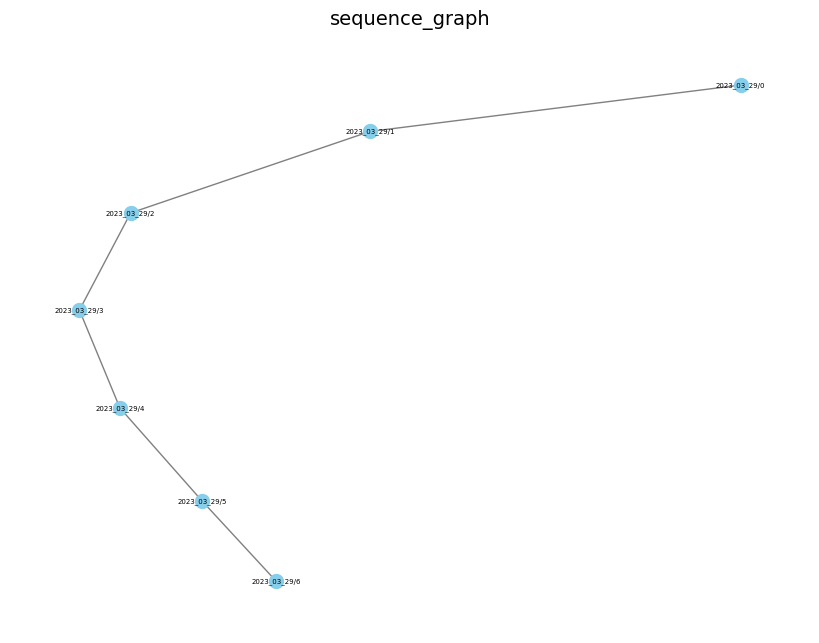

In [ ]:
sequence_graph = load_sequence_graph('/lab/kiran/navisim-1/assets/sequence_graph.gpickle')
plot_seq_graph(sequence_graph, out_path='/lab/kiran/navisim-1/assets')

In [ ]:
sectors = get_sectors(sequence_graph)
# sectors

In [ ]:
import random
import time
import ipywidgets as widgets
from IPython.display import display, clear_output
from shapely.geometry import Point
import open3d as o3d

# INITIAL SETUP
seq_id = list(sectors.keys())[0]
sector_id = 0
global_pos = None
elevation_map = global_pos
occupancy_map = None
polygon = None

output = widgets.Output()
display(output)

def check_coordinate(boundary, coo):
    x, y = coo
    minx, miny, maxx, maxy = polygon.bounds

    centroid = polygon.centroid
    cx, cy = centroid.x, centroid.y
    if x < cx:
        return boundary.covers(Point(x, y)), -1
    return boundary.covers(Point(x, y)), 1



import numpy as np
from shapely.geometry import Point

def find_nearest_accessible(polygon, occupancy_map):
    center = polygon.centroid
    x, y = int(center.x), int(center.y)
    
    if 0 <= x < occupancy_map.shape[1] and 0 <= y < occupancy_map.shape[0]:
        if occupancy_map[y, x] == 0:
            return (x, y)
    
    # Search nearby if center is not accessible
    for r in range(1, 10):  # Search radius
        for dx in range(-r, r + 1):
            for dy in range(-r, r + 1):
                nx, ny = x + dx, y + dy
                if (0 <= nx < occupancy_map.shape[1] and 0 <= ny < occupancy_map.shape[0]
                        and occupancy_map[ny, nx] == 0):
                    return (nx, ny)
    
    return (x, y)  # fallback if no accessible point found


def update_coordinate(direction, occupancy_map, coordinate, movement=1):
    x, y = coordinate

    moves = {
        'A': (-movement, 0),  # left
        'D': (movement, 0),   # right
        'W': (0, movement),   # up
        'S': (0, -movement),  # down
    }

    # Intended movement
    dx, dy = moves.get(direction, (0, 0))
    new_x, new_y = x + dx, y + dy

    # Check bounds
    if not (0 <= new_x < occupancy_map.shape[1] and 0 <= new_y < occupancy_map.shape[0]):
        print('out side the bounds')
        return (new_x, new_y)

    # Try normal movement first
    if occupancy_map[new_y, new_x] == 0:
        return (new_x, new_y)

    # Wall-following behavior: slide left/right or up/down
    # Prefer slight perpendicular movements to stick to the wall
    if direction in ['W', 'S']:  # moving vertically
        candidates = [
            (x - movement, y),  # left
            (x + movement, y),  # right
        ]
    elif direction in ['A', 'D']:  # moving horizontally
        candidates = [
            (x, y + movement),  # up
            (x, y - movement),  # down
        ]
    else:
        candidates = []

    # Try the candidates
    for nx, ny in candidates:
        if 0 <= nx < occupancy_map.shape[0] and 0 <= ny < occupancy_map.shape[1]:
            if occupancy_map[ny, nx] == 0:
                return (nx, ny)

    # If no wall-following move possible, stay
    return (x, y)

def benchmark(g, width=1280, height=720):
    vis = o3d.visualization.Visualizer()
    vis.create_window(width=width, height=height)
    vis.clear_geometries()
    vis.add_geometry(g)
    vis.poll_events()
    vis.update_renderer()

def move_agent(direction):
    global sector_id, global_pos, elevation_map, occupancy_map, polygon

    with output:
        clear_output(wait=True)

        if not direction:
            return

        start = time.time()

        if global_pos is None:
            # First time initialization
            elevation_map = get_elevation_map(seq_id, str(sector_id))
            occupancy_map = get_occupancy_map(seq_id, str(sector_id))
            polygon = get_polygon(seq_id, str(sector_id))
            center = polygon.centroid
            global_pos = find_nearest_accessible(polygon, occupancy_map)

        else:
            # Try moving based on input direction
            global_pos = update_coordinate(direction, occupancy_map, global_pos)

            # Update polygon
            polygon = get_polygon(seq_id, str(sector_id))
            is_agent_within_boundary, move_direction = check_coordinate(polygon, global_pos)

            if is_agent_within_boundary:
                elevation_map = get_elevation_map(seq_id, str(sector_id))
                occupancy_map = get_occupancy_map(seq_id, str(sector_id))
            else:
                # Crossed sector boundary
                sector_id = max(0, sector_id + move_direction)
                elevation_map = get_elevation_map(seq_id, str(sector_id))
                occupancy_map = get_occupancy_map(seq_id, str(sector_id))
                polygon = get_polygon(seq_id, str(sector_id))

                global_pos = find_nearest_accessible(polygon, occupancy_map)

        end = time.time()
        fps = 1 / (end - start)
        print(f"Direction: {direction} | Position: {global_pos} | FPS: {fps:.2f}")
        plot_maps(elevation_map, occupancy_map, polygon, global_pos)


Output()

In [ ]:
import random
import time

#directions = ['W', 'A', 'S', 'D']
directions = ['D']


def random_walk(steps=100, delay=0.5):
    for _ in range(steps):
        dir = random.choice(directions)
        # print(f"Moving {dir}")
        move_agent(dir)
        time.sleep(delay)

In [ ]:
random_walk(steps=200, delay=0.5)  # moves randomly 50 times with 0.3 sec delay

KeyboardInterrupt: 